Imports:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
gdp_df = pd.read_csv('../data/gdp_percapita.csv')
internet_df = pd.read_csv('../data/internet_use.csv', nrows = 6083)

In [6]:
gdp_df.head(5)

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN


In [7]:
gdp_df.tail(5)

,Country or Area,Year,Value,Value Footnotes
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN
8464,Zimbabwe,1990,6082.842451,NaN


In [9]:
gdp_df.shape

(8465, 4)

Rows: 8465
Columns: 4

In [10]:
gdp_column_types = gdp_df.dtypes
gdp_column_types

Country or Area     object
Year                 int64
Value              float64
Value Footnotes    float64
dtype: object

GDP DataFrame Column Types:

Country or Area     object
Year                 int64
Value              float64
Value Footnotes    float64
dtype: object

In [38]:
gdp_clean = gdp_df.drop(columns = ['Value Footnotes'])
gdp_clean

,Country or Area,Year,Value
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [39]:
gdp_clean.columns = ['Country', 'Year', 'GDP_Per_Capita']
gdp_clean.head(2)

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168


In [19]:
country_count = gdp_clean.Country.value_counts()
country_count

Country
Latin America & Caribbean (excluding high income)                 35
Nicaragua                                                         35
Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)    35
Middle income                                                     35
Moldova                                                           35
                                                                  ..
Cayman Islands                                                    18
Kosovo                                                            17
Faroe Islands                                                     17
Sint Maarten (Dutch part)                                         16
Djibouti                                                          12
Name: count, Length: 247, dtype: int64

In [33]:
country_count = country_count.rename(columns = {'count' : 'num_years'})
country_count

,num_years
Country,
Latin America & Caribbean (excluding high income),35
Nicaragua,35
"Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)",35
Middle income,35
Moldova,35
...,...
Cayman Islands,18
Kosovo,17
Faroe Islands,17


In [34]:
completion_count = country_count.value_counts()
completion_count = completion_count.to_frame()
completion_count.sort_values(by = 'num_years', ascending = False)

,count
num_years,
35,226
34,7
33,1
31,1
30,1
28,1
27,1
25,1
24,1


226 countries have data for all 35 years covered by the dataset.
21 countries are missing data for at least one year.
9 countries are missing data for more than 25% of the years covered by the dataset.
Kosovo, Faroe Islands, Sint Maarten (Dutch part), and Djibouti are missing data for more than half of the years covered by the dataset.

In [40]:
year_count = gdp_clean.Year.value_counts()
year_count = year_count.to_frame()
year_count.sort_values(by = 'Year', ascending = False)

,count
Year,
2024,236
2023,245
2022,247
2021,247
2020,247
2019,247
2018,247
2017,247
2016,247


The number of countries recorded steadily increases from 1990 to 2022, but then decreases in 2023 and 2024.

In [43]:
gdp_2020 = gdp_clean.loc[gdp_clean['Year'] == 2020]
gdp_2020 = gdp_2020.reset_index(drop = True)
gdp_2020

,Country,Year,GDP_Per_Capita
0,Afghanistan,2020,2769.685745
1,Africa Eastern and Southern,2020,3978.931395
2,Africa Western and Central,2020,5687.849988
3,Albania,2020,15659.588696
4,Algeria,2020,14194.155748
...,...,...,...
242,Virgin Islands (US),2020,45055.782930
243,West Bank and Gaza,2020,5423.682547
244,World,2020,18803.068884
245,Zambia,2020,3391.595412


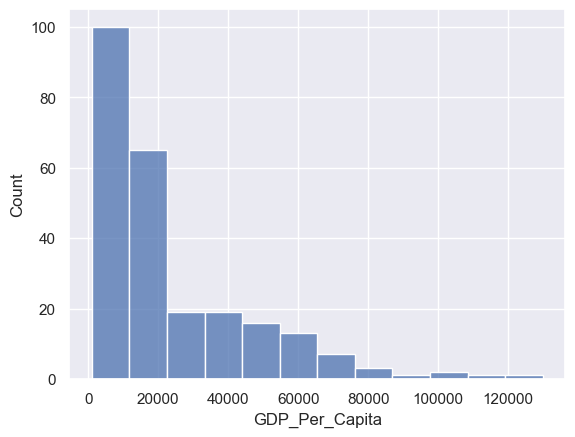

In [54]:
sns.set_theme(style="darkgrid")
sns.histplot(data=gdp_2020, x="GDP_Per_Capita", bins = 12)
plt.show()

<Axes: xlabel='GDP_Per_Capita', ylabel='Density'>

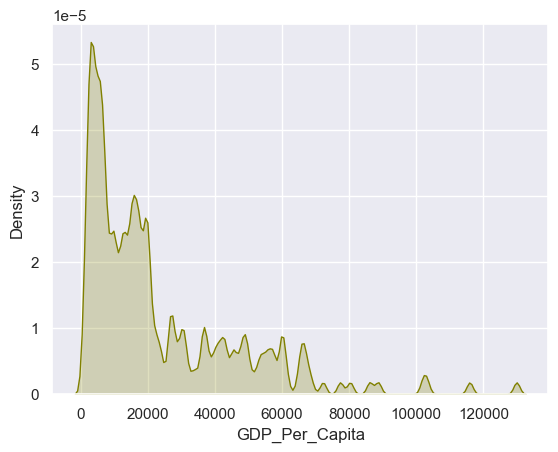

In [69]:
sns.kdeplot(gdp_2020['GDP_Per_Capita'], fill=True, color='olive', bw_method = 0.04)

<Axes: ylabel='GDP_Per_Capita'>

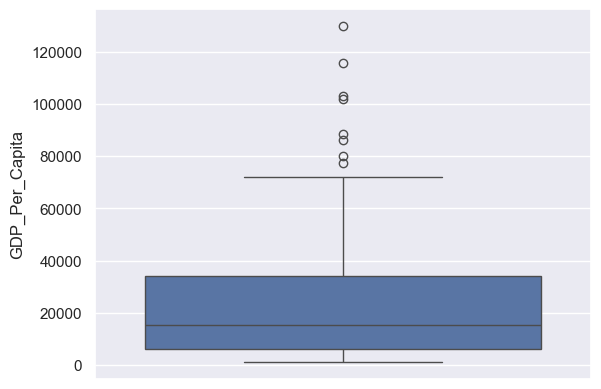

In [70]:
sns.boxplot(y=gdp_2020['GDP_Per_Capita'])

<Axes: ylabel='GDP_Per_Capita'>

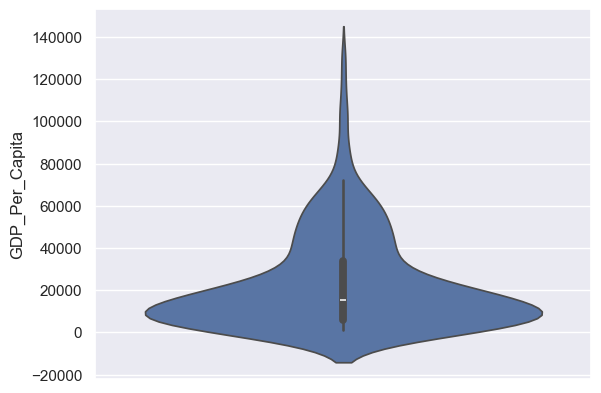

In [72]:
sns.violinplot(y = gdp_2020['GDP_Per_Capita'])

The histogram and density plots are more descriptive for this purpose since there is only one group to measure. The density plot in particular is probably the easiest to understand in this context. If we had pre-defined buckets for GDP values, the violin and box plots might be more descriptive. All four plots communicate the high density of countries with lower GDPs, but the density plot provides more granular information and the histogram provides an easy-to-understand visual. However, the box and violin plots provide additional data such as the quartile ranges and median value.

In [80]:
med_val_2020 = gdp_2020['GDP_Per_Capita'].median()
med_country_2020 = gdp_2020.loc[gdp_2020.GDP_Per_Capita == med_val_2020]
med_country_2020

,Country,Year,GDP_Per_Capita
97,IBRD only,2020,15399.308958


15399.308958 is the median GDP for 2020

In [109]:
decade_years = [1990, 2000, 2010, 2020]
gdp_decades = gdp_clean.loc[gdp_clean.Year.isin(decade_years)]
gdp_decades = gdp_decades.sort_values(by = 'Year')
gdp_decades = gdp_decades.reset_index(drop = True)
gdp_decades

,Country,Year,GDP_Per_Capita
0,Zimbabwe,1990,6082.842451
1,Sierra Leone,1990,2703.599187
2,Europe & Central Asia,1990,28177.752634
3,Euro area,1990,37825.251291
4,Singapore,1990,45567.790389
...,...,...,...
961,Guatemala,2020,11097.150412
962,Qatar,2020,103061.899445
963,Guinea,2020,3630.993306
964,Puerto Rico (US),2020,40171.386688


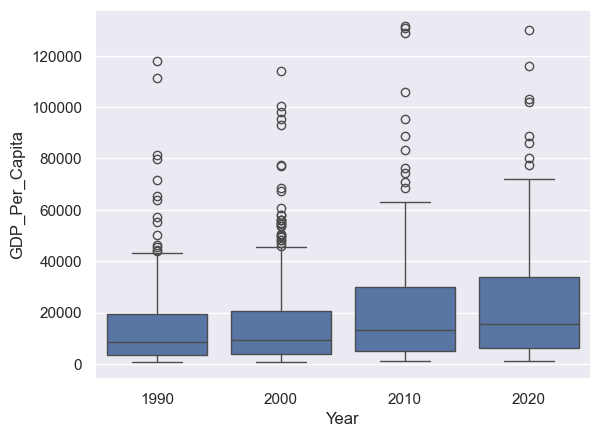

In [96]:
sns.boxplot(x = gdp_decades['Year'], y = gdp_decades['GDP_Per_Capita'])
plt.show()

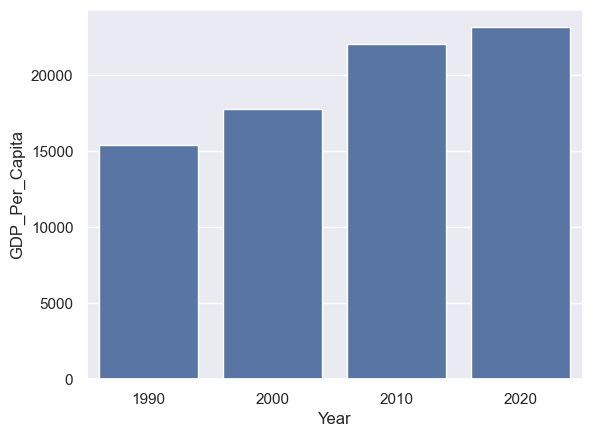

In [95]:
sns.barplot(x = gdp_decades['Year'], y = gdp_decades['GDP_Per_Capita'], errorbar = None)
plt.show()

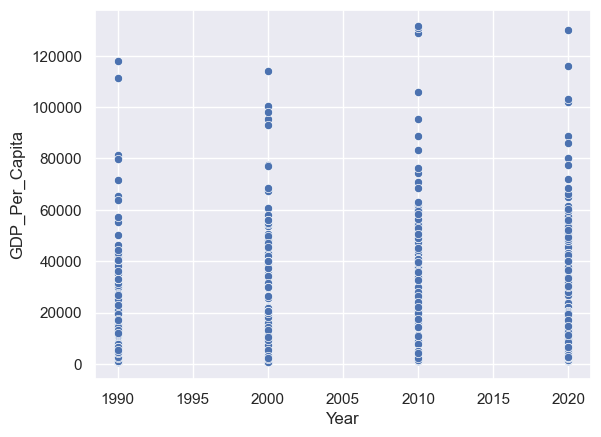

In [98]:
sns.scatterplot(x = gdp_decades['Year'], y = gdp_decades['GDP_Per_Capita'])
plt.show()

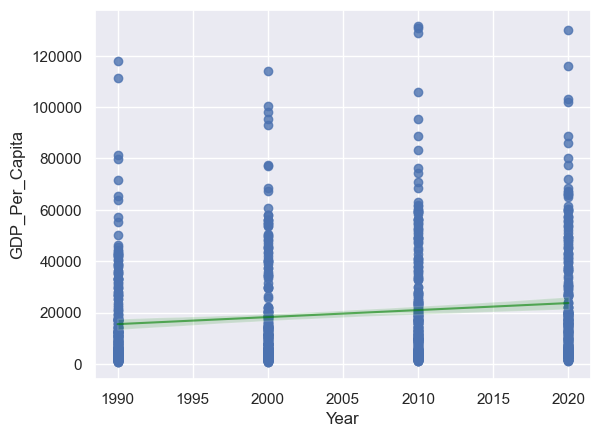

In [106]:
sns.regplot(x = gdp_decades['Year'], y = gdp_decades['GDP_Per_Capita'], line_kws = {"color": "green", "linewidth": 1.5, "alpha": 0.6})
plt.show()

Overall, global GDP per capita has increased over time. Of these charts, the box plot provides the most information, but the barplot is the easiest to interpret. The scatter plots are useful, especially the one with the trendline included, but they're a bit hard to read since there are only a few discrete years displayed.

In [110]:
gdp_over_100k = gdp_clean.loc[gdp_clean.GDP_Per_Capita >= 100000]
gdp_over_100k = gdp_over_100k.reset_index(drop = True)
gdp_over_100k

,Country,Year,GDP_Per_Capita
0,Bermuda,2024,109311.936941
1,Bermuda,2023,103052.348368
2,Bermuda,2011,101989.927296
3,Bermuda,2010,105968.875104
4,Bermuda,2009,108962.816946
...,...,...,...
110,United Arab Emirates,1994,102456.104720
111,United Arab Emirates,1993,100422.631522
112,United Arab Emirates,1992,104206.754891
113,United Arab Emirates,1991,106266.193694


In [115]:
first_gdp_over_100k = gdp_over_100k.loc[gdp_over_100k['Year'] == gdp_over_100k['Year'].min()]
first_gdp_over_100k

,Country,Year,GDP_Per_Capita
25,Brunei Darussalam,1990,118163.68337
114,United Arab Emirates,1990,111377.04689


Brunei Darussalam and United Arab Emirates both had GDP per capita over 100,000 in 1990, which is the earliest year covered by the dataset.

In [119]:
max_gdp_2020 = gdp_clean.loc[gdp_clean['GDP_Per_Capita'] == gdp_clean['GDP_Per_Capita'].max()]
max_gdp_2020

,Country,Year,GDP_Per_Capita
4671,"Macao SAR, China",2013,174569.523171


In [120]:
macao_gdp = gdp_clean.loc[gdp_clean.Country == 'Macao SAR, China']
macao_gdp = macao_gdp.reset_index(drop = True)
macao_gdp

,Country,Year,GDP_Per_Capita
0,"Macao SAR, China",2024,111693.502831
1,"Macao SAR, China",2023,104815.200031
2,"Macao SAR, China",2022,59921.441692
3,"Macao SAR, China",2021,73374.448683
4,"Macao SAR, China",2020,59662.485586
5,"Macao SAR, China",2019,133453.896026
6,"Macao SAR, China",2018,139541.157249
7,"Macao SAR, China",2017,133322.632678
8,"Macao SAR, China",2016,120530.052858
9,"Macao SAR, China",2015,123194.067291


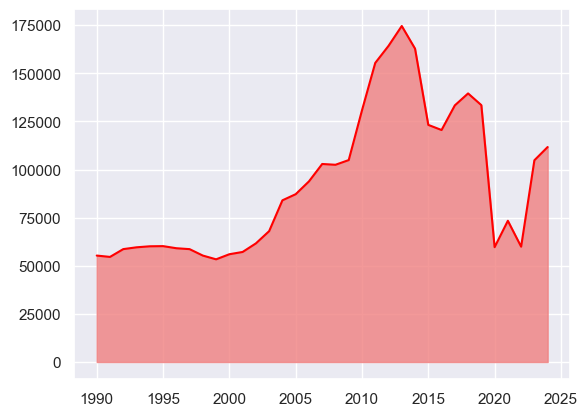

In [122]:
plt.fill_between(macao_gdp.Year, macao_gdp.GDP_Per_Capita, color = 'lightcoral', alpha = 0.8)
plt.plot(macao_gdp.Year, macao_gdp.GDP_Per_Capita, color = 'red')
plt.show()

In [116]:
min_gdp_2020 = gdp_clean.loc[gdp_clean['GDP_Per_Capita'] == gdp_clean['GDP_Per_Capita'].min()]
min_gdp_2020

,Country,Year,GDP_Per_Capita
5385,Mozambique,1992,510.822823


In [118]:
mzb_gdp = gdp_clean.loc[gdp_clean.Country == 'Mozambique']
mzb_gdp = mzb_gdp.reset_index(drop = True)
mzb_gdp

,Country,Year,GDP_Per_Capita
0,Mozambique,2024,1500.314274
1,Mozambique,2023,1512.276408
2,Mozambique,2022,1476.665603
3,Mozambique,2021,1457.235409
4,Mozambique,2020,1466.124765
5,Mozambique,2019,1528.889884
6,Mozambique,2018,1538.835121
7,Mozambique,2017,1532.007358
8,Mozambique,2016,1537.908533
9,Mozambique,2015,1512.599746


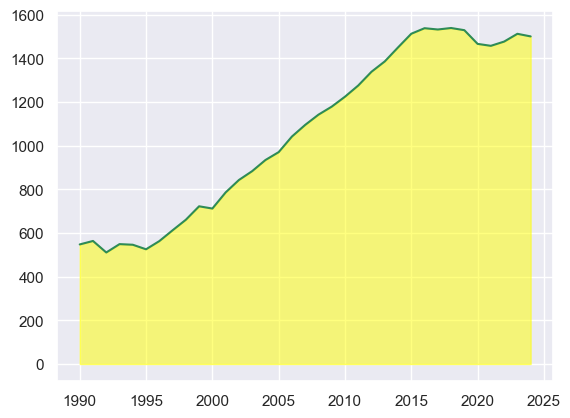

In [124]:
plt.fill_between(mzb_gdp.Year, mzb_gdp.GDP_Per_Capita, color = 'yellow', alpha = 0.5)
plt.plot(mzb_gdp.Year, mzb_gdp.GDP_Per_Capita, color = 'seagreen')
plt.show()

gdp_1990 = gdp_clean.loc[gdp_clean['Year'] == 1990]
higher_gdp_2020 = gdp_clean.loc[gdp_2020.GDP_Per_Capita > gdp_1990.GDP_Per_Capita]
higher_gdp_2020

In [21]:
internet_df.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.60,1
1,Afghanistan,2018,16.80,2
2,Afghanistan,2017,13.50,3
3,Afghanistan,2016,11.00,4
4,Afghanistan,2015,8.26,4


In [138]:
internet_df.tail()

,Country or Area,Year,Value,Value Footnotes
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN
6082,Zimbabwe,1990,0.000000,NaN


In [14]:
internet_df.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes     object
dtype: object

In [22]:
internet_df = internet_df.drop(columns = ['Value Footnotes'])

In [23]:
internet_df.columns = ['Country', 'Year', 'Internet_Users_Pct']

In [24]:
internet_df.columns

Index(['Country', 'Year', 'Internet_Users_Pct'], dtype='object')

In [4]:
internet_obs_yearly = internet_df.Year.value_counts()

In [5]:
internet_obs_yearly = internet_obs_yearly.to_frame()

In [7]:
internet_obs_yearly = internet_obs_yearly.sort_values(by = 'Year')

In [8]:
internet_obs_yearly

,count
Year,
1990,226
1991,39
1992,50
1993,66
1994,92
1995,141
1996,177
1997,188
1998,195


The number of observations is 226 in 1990 but then drops to 39 in 1991 and doesn't climb back into the 200s until 1999. Also, the number of observations is unusually low in 2023.

In [25]:
nonzero_internet = internet_df.loc[internet_df['Internet_Users_Pct'] != 0]
nonzero_internet.value_counts()

Country      Year  Internet_Users_Pct
Afghanistan  2001  0.004723              1
Nicaragua    2022  61.052400             1
             2020  54.854300             1
             2019  44.916400             1
             2018  37.600000             1
                                        ..
France       2021  86.095500             1
             2020  84.706400             1
             2019  83.339700             1
             2018  82.043200             1
Zimbabwe     2022  32.561500             1
Name: count, Length: 5803, dtype: int64

In [26]:
first_internet_year = nonzero_internet.Year.min()
first_internet_year

1990

In [28]:
internet_2000 = internet_df[internet_df.Year == 2000]
internet_2000

,Country,Year,Internet_Users_Pct
42,Albania,2000,0.114097
71,Algeria,2000,0.491706
100,Andorra,2000,10.538800
128,Angola,2000,0.105046
150,Anguilla,2000,22.405400
...,...,...,...
5974,Virgin Islands (US),2000,13.815100
5994,Wallis and Futuna,2000,4.768070
6017,Yemen,2000,0.082500
6045,Zambia,2000,0.191072


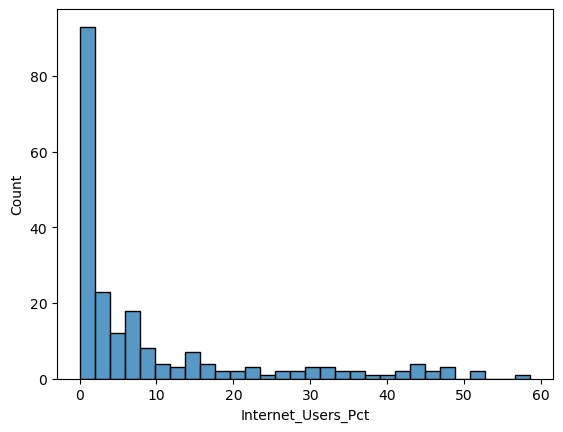

In [33]:
sns.histplot(data=internet_2000, x="Internet_Users_Pct", bins = 30)
plt.show()

In [31]:
internet_2014 = internet_df[internet_df.Year == 2014]
internet_2014

,Country,Year,Internet_Users_Pct
5,Afghanistan,2014,7.0000
28,Albania,2014,54.3000
57,Algeria,2014,29.5000
87,Andorra,2014,86.1000
114,Angola,2014,21.3623
...,...,...,...
5937,Viet Nam,2014,41.0000
5960,Virgin Islands (US),2014,50.0700
6003,Yemen,2014,22.5500
6031,Zambia,2014,6.5000


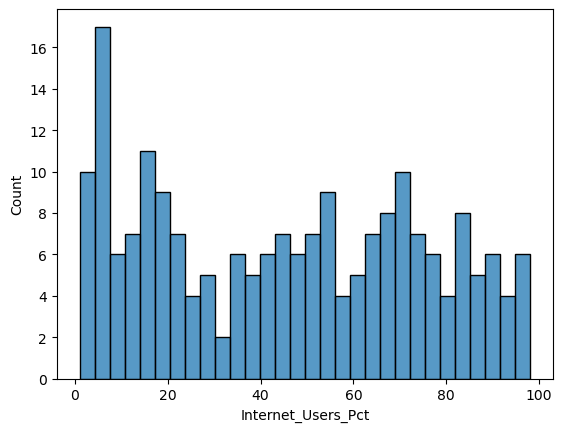

In [34]:
sns.histplot(data=internet_2014, x="Internet_Users_Pct", bins = 30)
plt.show()

In 2000 the vast majority countries had an internet use percentage less than 10%, and no country had usage above 60%.
In 2014 many nations still had usage less than 10%, but a majority of countries were over 20% and some countries are approaching 100%.

In [36]:
below_5_2014 = internet_2014.loc[internet_2014.Internet_Users_Pct < 5]
below_5_2014.shape

(10, 3)

10 countries had usage below 5% in 2014

In [40]:
gdp_and_internet_use = pd.concat([gdp_clean, internet_df])
gdp_and_internet_use = gdp_and_internet_use.reset_index(drop = True)
gdp_and_internet_use

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
14543,Zimbabwe,1997,NaN,0.033080
14544,Zimbabwe,1996,NaN,0.016790
14545,Zimbabwe,1995,NaN,0.007684
14546,Zimbabwe,1994,NaN,0.001739


In [48]:
highest_internet_2014 = gdp_and_internet_use.loc[gdp_and_internet_use.Year == 2014].sort_values(by = ['Internet_Users_Pct'], ascending = False)
highest_internet_2014 = highest_internet_2014.head(3)
highest_internet_2014

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
11057,Iceland,2014,NaN,98.158
10358,Falkland (Malvinas) Islands,2014,NaN,97.600
9067,Bermuda,2014,NaN,96.800


In [50]:
ice_falk_berm = pd.concat([gdp_and_internet_use.loc[gdp_and_internet_use.Country == 'Iceland'], 
                           gdp_and_internet_use.loc[gdp_and_internet_use.Country == 'Falkland (Malvinas) Islands'],
                            gdp_and_internet_use.loc[gdp_and_internet_use.Country == 'Bermuda']])
ice_falk_berm

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
3349,Iceland,2024,67310.057357,NaN
3350,Iceland,2023,68118.396031,NaN
3351,Iceland,2022,65380.317305,NaN
3352,Iceland,2021,61610.213274,NaN
3353,Iceland,2020,59543.813499,NaN
...,...,...,...,...
9083,Bermuda,1998,NaN,32.10380
9084,Bermuda,1997,NaN,24.18930
9085,Bermuda,1996,NaN,16.20250
9086,Bermuda,1995,NaN,6.83816


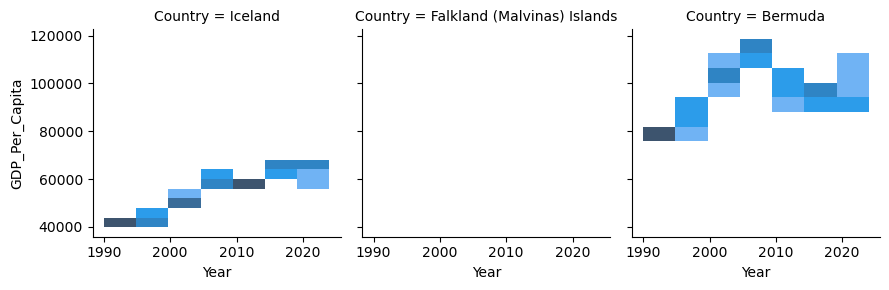

In [53]:
g = sns.FacetGrid(ice_falk_berm, col="Country")
g.map_dataframe(sns.histplot, x="Year", y="GDP_Per_Capita")